## 6.S083 / 18.S190
# PSET 4 Solution – Disease Dynamics

#### Author: Dan Segal (@[djsegal](https://github.com/djsegal))

----


In this problem set, we will look at the simplest epidemic model in which
we take **space** into account

+ the simplest way to do this is to use **discrete space**: each agent lives
in a cell of a square grid
+ the effect of space is thus to *restrict* the set of other agents with which
a given agent can interact at a time

## Exercise 1: Moving in 2D

### 1. Define an abstract type `AbstractWalker`


In [1]:
abstract type AbstractWalker end


### 2. Define an abstract type `AbstractWalker2D` that is a subtype of `AbstractWalker`


In [2]:
abstract type AbstractWalker2D <: AbstractWalker end


### 3. Define an immutable type `Location` that contains integers `x` and `y`


In [3]:
struct Location
  x::Int
  y::Int
end


### 4. Define a `Walker2D` type that is a subtype of `AbstractWalker2D`
It should contain a field `position` that is a `Location` object



In [4]:
mutable struct Walker2D <: AbstractWalker2D
  position::Location
end


### 5. Check that Julia automatically provides a constructor function 

+ `Walker2D(position)` that accepts an object of type `Location`
+ Construct a `Walker` located at the origin.



In [5]:
walker_at_origin = Walker2D(Location(0,0))

@assert walker_at_origin.position.x == 0
@assert walker_at_origin.position.y == 0


### 6. Write a new method of the constructor for `Walker2D` that accepts two integers, $x$ and $y$


In [6]:
Walker2D(x::Int, y::Int) = Walker2D(Location(x, y)) 

@assert Walker2D(0,0).position == walker_at_origin.position


### 7. Write a function `make_tuple` 

+ that takes an object of type `Location`
+ and returns the corresponding tuple `(x, y)`


In [7]:
make_tuple(position::Location) = (position.x, position.y)

@assert make_tuple(walker_at_origin.position) == (0, 0)


### 8. Write a getter function `pos` that returns the position as a `Location` object



In [8]:
pos(walker::AbstractWalker2D) = walker.position


pos (generic function with 1 method)

### 9. Write a setter function `set_pos!` that sets the position to a given location `l`



In [9]:
function set_pos!(walker::AbstractWalker2D, l::Location)
  walker.position = l
  walker
end


set_pos! (generic function with 1 method)

### 10. Write a function `jump` that returns a new position for a walker after a jump
+ Jumps are equally likely in the directions right, up, left and down
+ A nice way to implement this is to make a tuple `neighbours` of possible
    destinations


In [10]:
function jump(walker::AbstractWalker2D)
  cur_position = pos(walker)
  
  new_tuple = collect(make_tuple(cur_position))
  new_tuple[rand(1:2)] += rand([-1,+1])
  
  Location(new_tuple...)
end


jump (generic function with 1 method)


### 11. Write a function `jump!` that moves a walker to a new position
+ What arguments does the function need?
+ Use your `jump` function to write `jump!`


In [11]:
function jump!(walker::AbstractWalker2D)
  set_pos!(walker, jump(walker))
  walker
end


jump! (generic function with 1 method)

### 12. Write a function `trajectory` 
that calculates a trajectory of a 2D walker of length $N$



In [12]:
function trajectory(init_walker::AbstractWalker2D, N::Int)
  walker = deepcopy(init_walker)
  [ make_tuple(pos(jump!(walker))) for _ in 1:N ]
end


trajectory (generic function with 1 method)

### 13. Plot 10 trajectories of length 10,000 on a single figure, all starting at the origin


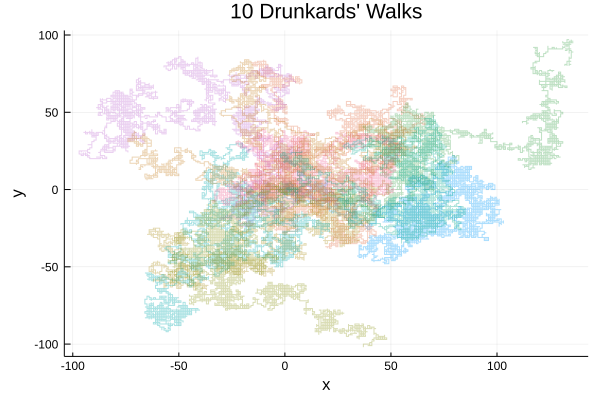

In [13]:
using Plots

m = 10
N = 10^4

plot(xlabel="x", ylabel="y")
for _ in 1:m
  plot!(trajectory(walker_at_origin, N), label="", alpha=1/3)
end
plot!(title="10 Drunkards' Walks")

-----

## Exercise 2: Making agents move

Now we'll combine the `Agent` type from before with the 2D random walker

### 1. Define a mutable type `Agent` that is a subtype of `AbstractWalker2D` 

`Agent` should contain a `position` of type `Location`, as well as a `state` of type `InfectionStatus`


In [14]:
@enum InfectionStatus S I R

mutable struct Agent <: AbstractWalker2D
  position::Location
  state::InfectionStatus
end



### 2. Agents live in a box of side length `L`, centered at the origin

+ We need to decide what happens when they reach the walls of the box
+ i.e. what kind of **boundary conditions** to use


In [15]:
function jump(walker::Agent, L::Int)
  tmp_position = jump(walker)
  tmp_tuple = make_tuple(tmp_position)
  
  r_max = ceil(+(L-1)/2)
  p_max = maximum(tmp_tuple)
  ( p_max > r_max ) && return pos(walker)
  
  r_min = ceil(-(L-1)/2)
  p_min = minimum(tmp_tuple)
  ( p_min < r_min ) && return pos(walker)
  
  tmp_position
end


jump (generic function with 2 methods)


### 3. Check that this is working by drawing a trajectory of an `Agent` inside a square box of side length 20


In [16]:
some_agent = Agent(walker_at_origin.position, S)

function jump!(walker::Agent, L::Int)
  set_pos!(walker, jump(walker, L))
  walker
end

function trajectory(init_walker::Agent, N::Int, L::Int)
  walker = deepcopy(init_walker)
  [ make_tuple(pos(jump!(walker, L))) for _ in 1:N ]
end


trajectory (generic function with 2 methods)

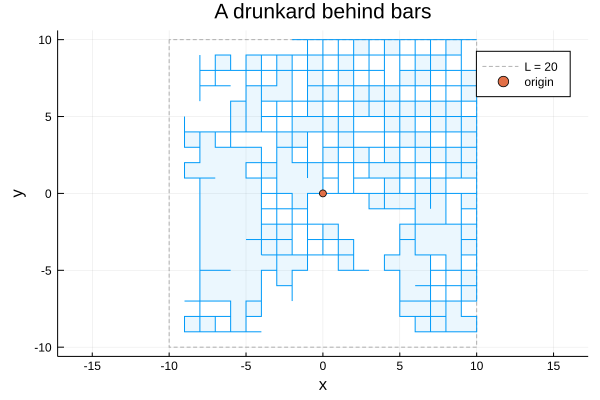

In [17]:
N = 2 * 10^3
L = 20

plot(xlabel="x", ylabel="y")
plot!([-10,-10,10,10,-10],[10,-10,-10,10,10], color="grey", label="L = 20", opacity=0.6, linestyle=:dash)
plot!(trajectory(some_agent, N, L), label="", color=1, fillopacity=0.08, fill=true)
scatter!([0],[0], c=2, label="origin")
plot!(title="A drunkard behind bars", ratio=1)


---

## Exercise 3: Spatial epidemic model  – Initialization and visualization

We now have all of the technology in place to simulate an agent-based model in space!

### 1. Write a function `initialize` 
+ that takes parameters $L$ – the side length of the box – and $N$, the number of agents
+ it should build, one by one, a collection of agents, by proposing a position for each one and checking if that position is occupied
+ if the position is occupied, it should generate another one, and so on until it finds a free spot


In [18]:
function initialize(L::Int, N::Int)
  @assert N <= L^2
  
  agents = Agent[]
  cur_range = Int(ceil(-(L-1)/2)):Int(ceil(+(L-1)/2))

  cur_set = Set{Location}()
  for i in 1:N
    while true
      tmp_position = Location(rand(cur_range),rand(cur_range))
      ( tmp_position in cur_set ) && continue
      
      push!(cur_set, tmp_position)
      push!(agents, Agent(tmp_position, S))
      
      break
    end
  end
  
  agents[1].state = I
  agents
end

initialize (generic function with 1 method)

In [19]:
initialize(2, 4)


4-element Array{Agent,1}:
 Agent(Location(1, 0), I)
 Agent(Location(0, 1), S)
 Agent(Location(1, 1), S)
 Agent(Location(0, 0), S)

### 2. Run your initialization function for $L=10$ and $N=20$


In [20]:
L = 10
N = 20

cur_agents = initialize(L, N)


20-element Array{Agent,1}:
 Agent(Location(5, -1), I)
 Agent(Location(1, 0), S)
 Agent(Location(-3, 3), S)
 Agent(Location(3, 0), S)
 Agent(Location(-3, -2), S)
 Agent(Location(1, -4), S)
 Agent(Location(4, 3), S)
 Agent(Location(0, -4), S)
 Agent(Location(-2, 1), S)
 Agent(Location(5, -3), S)
 Agent(Location(-2, 2), S)
 Agent(Location(5, 4), S)
 Agent(Location(4, 1), S)
 Agent(Location(-2, -1), S)
 Agent(Location(-3, 4), S)
 Agent(Location(2, 0), S)
 Agent(Location(-1, 4), S)
 Agent(Location(2, -2), S)
 Agent(Location(1, 3), S)
 Agent(Location(0, -3), S)

### 3. Write a function `visualize_agents` 
+ that takes in a collection of agents as argument
+ it should plot a point for each agent, coloured according to its status


In [21]:
function visualize_agents(agents::Vector{Agent})
  scatter(
    make_tuple.(pos.(agents)), 
    c=1 .- map((agent) -> Int(agent.state), agents),
    ratio=1, label=""
  )
end


visualize_agents (generic function with 1 method)


### 4. Run the function to visualize the initial condition you created

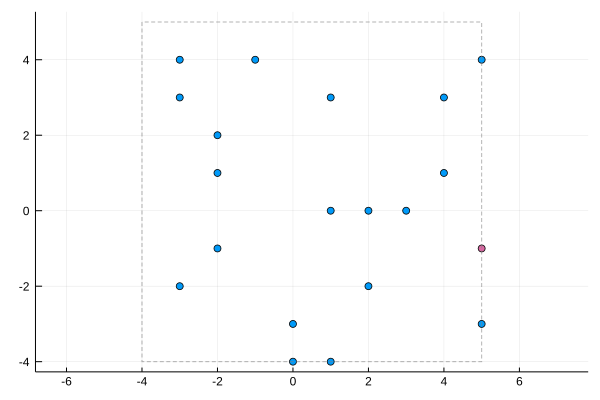

In [22]:
visualize_agents(cur_agents)

plot!(
  [-4,-4,5,5,-4], [5,-4,-4,5,5], 
  color="grey", label="", 
  opacity=0.6, linestyle=:dash
)


----

## Exercise 4: Spatial epidemic model – Dynamics

### 1. Write a function `step!` that does one step of the dynamics of the model
It takes as parameters $L$, $p_I$ and $p_R$


In [23]:
bernoulli(p) = rand() <= p

# If agent $i$ is infected and agent $j$ is susceptible 
#  agent $j$ becomes infected with probability $p_I$
function infect!(agent_i, agent_j, p_I)
  ( agent_i.state == I ) || return
  ( agent_j.state == S ) || return

  bernoulli(p_I) || return
  agent_j.state = I
end

# If agent $i$ is infected,
# it recovers with prob $p_R$
function recover!(agent_i, p_R)
  ( agent_i.state == I ) || return
  bernoulli(p_R) || return

  agent_i.state = R
end

function step!(agents::Vector{Agent}, L::Int, p_I::Number, p_R::Number)
  
  # choose agent at random
  i = rand(1:length(agents))
  agent_i = agents[i]

  # suggest new position
  proposed_position = jump(agent_i, L)
  if ( proposed_position == pos(agent_i) ) 
    recover!(agent_i, p_R)
    return agents
  end

  # agent moves there if unoccupied
  if !( proposed_position in pos.(agents) )
    set_pos!(agent_i, proposed_position)
    recover!(agent_i, p_R)
    return agents
  end

  j = findfirst(
    (cur_agent) -> pos(cur_agent) == proposed_position, 
    agents
  )
  
  agent_j = agents[j]
  @assert agent_i != agent_j

  infect!(agent_i, agent_j, p_I)
  recover!(agent_i, p_R)

  agents
end


step! (generic function with 1 method)


### 2. Make a small system and run the `step!` function a few times
To check (by eye) that it's doing the right thing


In [24]:
LL = 2
NN = 4

tmp_agents = initialize(LL, NN)
[ step!(tmp_agents, LL, 1.0, 0.0) for _ in 1:10000 ]
@assert map(tmp_agent -> Int(tmp_agent.state), tmp_agents) == [1,1,1,1]

tmp_agents = initialize(LL, NN)
[ step!(tmp_agents, LL, 0.0, 1.0) for _ in 1:10000 ]
@assert map(tmp_agent -> Int(tmp_agent.state), tmp_agents) == [2,0,0,0]


### 3. Make an interactive visualization to display the agents after each step
To again check visually that the implementation is correct



In [25]:
using Interact

L = 10
N = 20
T = 30

p_I = 0.1
p_R = 0.01

cur_agents = initialize(L, N)
agents_time_series = [ 
  deepcopy(step!(cur_agents, L, p_I, p_R)) for _ in 1:T 
]

@manipulate for i in slider(1:T, value=1, label="i")
  visualize_agents(agents_time_series[i])

  plot!(
    [-4,-4,5,5,-4], [5,-4,-4,5,5], 
    color="grey", label="", 
    opacity=0.6, linestyle=:dash
  )
  
  xlims!(ceil(-(L-1)/2)-2, ceil(+(L-1)/2)+2)
  ylims!(ceil(-(L-1)/2)-2, ceil(+(L-1)/2)+2)
end


HTML{String}("<script>\n// Immediately-invoked-function-expression to avoid global variables.\n(function() {\n    var warning_div = document.getElementById(\"webio-warning-1929808704911108932\");\n    var hide = function () {\n        var script = document.getElementById(\"webio-setup-3056112827588017369\");\n        var parent = script && script.parentElement;\n        var grandparent = parent && parent.parentElement;\n        if (grandparent) {\n            grandparent.style.display = \"none\";\n        }\n        warning_div.style.display = \"none\";\n    };\n    if (typeof Jupyter !== \"undefined\") {\n        console.log(\"WebIO detected Jupyter notebook environment.\");\n        // Jupyter notebook.\n        var extensions = (\n            Jupyter\n            && Jupyter.notebook.config.data\n            && Jupyter.notebook.config.data.load_extensions\n        );\n        if (extensions && extensions[\"webio-jupyter-notebook\"]) {\n            // Extension already loaded.\n            console.log(\"Jupyter WebIO nbextension detected; not loading ad-hoc.\");\n            hide();\n            return;\n        }\n    } else if (window.location.pathname.includes(\"/lab\")) {\n        // Guessing JupyterLa\n        console.log(\"Jupyter Lab detected; make sure the @webio/jupyter-lab-provider labextension is installed.\");\n        hide();\n        return;\n    }\n})();\n\n</script>\n<p\n    id=\"webio-warning-1929808704911108932\"\n    class=\"output_text output_stderr\"\n    style=\"padding: 1em; font-weight: bold;\"\n>\n    Unable to load WebIO. Please make sure WebIO works for your Jupyter client.\n    For troubleshooting, please see <a href=\"https://juliagizmos.github.io/WebIO.jl/latest/providers/ijulia/\">\n    the WebIO/IJulia documentation</a>.\n    <!-- TODO: link to installation docs. -->\n</p>\n")

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["i"], Dict{Symbol,Any}(:className => "interact ",:style => Dict{Any,Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol,Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol,Any}(:max => 30,:min => 1,:attributes => Dict{Any,Any}(:type => "range",Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}","orient" => "horizontal"),:step => 1,:className => "slider slider is-fullwidth",:style => Dict{Any,Any}()))], Dict{Symbol,Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol,Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol,Any}(:className => "interact-flex-row-right"))], Dict{Symbol,Any}(:className => "interact-flex-row interact-widget")), Dict{String,Tuple{Observables.AbstractObservable,Union{Nothing, Bool}}}("changes" => (Observable{Int64} with 1 listeners. Value:
0, nothing),"index" => (Observable{Int64} with 2 listeners. Value:
1, nothing)), Set(String[]), nothing, Asset[Asset("js", "knockout", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/all.js"), Asset("css", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/style.css"), Asset("css", nothing, "/Users/dan/.julia/packages/Interact/SbgIk/src/../assets/bulma_confined.min.css")], Dict{Any,Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")],"index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(sz_max:32,sz_curr:0), Set(AbstractConnection[]), Base.GenericCondition{Base.AlwaysLockedST}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x0000000114515210, Task (runnable) @0x0000000114515210), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\",\"6\",\"7\",\"8\",\"9\",\"10\",\"11\",\"12\",\"13\",\"14\",\"15\",\"16\",\"17\",\"18\",\"19\",\"20\",\"21\",\"22\",\"23\",\"24\",\"25\",\"26\",\"27\",\"28\",\"29\",\"30\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":

### 4. Write a function `sweep!` that performs one sweep of $N$ steps



In [26]:
function sweep!(agents::Vector, L::Int, p_I::Number, p_R::Number) 
  [ step!(agents, L, p_I, p_R) for _ in 1:length(agents) ]
end


sweep! (generic function with 1 method)

### 5. Write a function `dynamics!` 
That runs the dynamics for the given number of sweeps


In [27]:
function dynamics!(agents::Vector, L::Int, p_I::Number, p_R::Number, T::Int) 
  Ss, Is, Rs = [ zeros(Int, T) for _ in 1:3 ]
  cur_states = []
  
  for t in 1:T
    sweep!(agents, L, p_I, p_R)
    push!(cur_states, deepcopy(agents))
    
    Ss[t] = count((agent) -> agent.state == S, agents)
    Is[t] = count((agent) -> agent.state == I, agents)
    Rs[t] = count((agent) -> agent.state == R, agents)
  end
  
  return cur_states, Ss, Is, Rs
end


dynamics! (generic function with 1 method)


### 6. Given one simulation run, write an interactive visualization
+ that shows both the state at time $n$ (using `visualize_agents`) 
+ and the history of $S$, $I$ and $R$ from time $0$ up to time $n$


In [28]:
function custom_plot(cur_states, Ss, Is, Rs, i, L, is_simple=false)
  p1 = visualize_agents(cur_states[max(1,i)])

  min_val = ceil(-(L-1)/2)
  max_val = ceil(+(L-1)/2)
  
  plot!(
    [min_val,min_val,max_val,max_val,min_val], 
    [max_val,min_val,min_val,max_val,max_val], 
    color="grey", label="", 
    opacity=0.6, linestyle=:dash,
    title="Agent Grid [t=$(i)]",
    xlabel="x", ylabel="y"
  )
  
  xlims!(min_val-2, max_val+2)
  ylims!(min_val-2, max_val+2)
  
  p2 = plot(xlim=(1,T), ylim=(-1,N+1))
  plot!(Ss[1:i], label="S")
  plot!(Is[1:i], label="I")
  iszero(maximum(Rs)) || plot!(Rs[1:i], label="R")
  plot!(xlabel="T", ylabel="N", title="Time Series")
  
  if is_simple
    cur_layout = @layout [ a{0.4w} b{0.6w} ]
    plot(p1, p2, layout=cur_layout, size=(1000,400))
  else
    hbox(p1,p2)
  end
end

custom_plot (generic function with 2 methods)

In [29]:
L = 10
N = 20
T = 30

p_I = 0.1
p_R = 0.01

cur_agents = initialize(L, N)
cur_states, Ss, Is, Rs = dynamics!(cur_agents, L, p_I, p_R, T) 

@manipulate for i in slider(1:T, value=1, label="i")
  custom_plot(cur_states, Ss, Is, Rs, i, L)
end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["i"], Dict{Symbol,Any}(:className => "interact ",:style => Dict{Any,Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol,Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol,Any}(:max => 30,:min => 1,:attributes => Dict{Any,Any}(:type => "range",Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}","orient" => "horizontal"),:step => 1,:className => "slider slider is-fullwidth",:style => Dict{Any,Any}()))], Dict{Symbol,Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol,Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol,Any}(:className => "interact-flex-row-right"))], Dict{Symbol,Any}(:className => "interact-flex-row interact-widget")), Dict{String,Tuple{Observables.AbstractObservable,Union{Nothing, Bool}}}("changes" => (Observable{Int64} with 1 listeners. Value:
0, nothing),"index" => (Observable{Int64} with 2 listeners. Value:
1, nothing)), Set(String[]), nothing, Asset[Asset("js", "knockout", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/all.js"), Asset("css", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/style.css"), Asset("css", nothing, "/Users/dan/.julia/packages/Interact/SbgIk/src/../assets/bulma_confined.min.css")], Dict{Any,Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")],"index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(sz_max:32,sz_curr:0), Set(AbstractConnection[]), Base.GenericCondition{Base.AlwaysLockedST}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x0000000113287850, Task (runnable) @0x0000000113287850), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\",\"6\",\"7\",\"8\",\"9\",\"10\",\"11\",\"12\",\"13\",\"14\",\"15\",\"16\",\"17\",\"18\",\"19\",\"20\",\"21\",\"22\",\"23\",\"24\",\"25\",\"26\",\"27\",\"28\",\"29\",\"30\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":

### 7. Using $L=20$ and $N=100$, experiment with $p_I$ and $p_R$ until you find an epidemic outbreak
// take $p_R$ quite small



In [30]:
L = 20
N = 100
T = 501

p_I = 1/3
p_R = 0.01

cur_agents = initialize(L, N)
cur_states, Ss, Is, Rs = dynamics!(cur_agents, L, p_I, p_R, T) 

@manipulate for i in slider(1:25:T, value=1, label="i")
  custom_plot(cur_states, Ss, Is, Rs, i, L)
end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["i"], Dict{Symbol,Any}(:className => "interact ",:style => Dict{Any,Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol,Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol,Any}(:max => 21,:min => 1,:attributes => Dict{Any,Any}(:type => "range",Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}","orient" => "horizontal"),:step => 1,:className => "slider slider is-fullwidth",:style => Dict{Any,Any}()))], Dict{Symbol,Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol,Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol,Any}(:className => "interact-flex-row-right"))], Dict{Symbol,Any}(:className => "interact-flex-row interact-widget")), Dict{String,Tuple{Observables.AbstractObservable,Union{Nothing, Bool}}}("changes" => (Observable{Int64} with 1 listeners. Value:
0, nothing),"index" => (Observable{Any} with 2 listeners. Value:
1, nothing)), Set(String[]), nothing, Asset[Asset("js", "knockout", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/all.js"), Asset("css", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/style.css"), Asset("css", nothing, "/Users/dan/.julia/packages/Interact/SbgIk/src/../assets/bulma_confined.min.css")], Dict{Any,Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")],"index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(sz_max:32,sz_curr:0), Set(AbstractConnection[]), Base.GenericCondition{Base.AlwaysLockedST}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x00000001145158d0, Task (runnable) @0x00000001145158d0), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"26\",\"51\",\"76\",\"101\",\"126\",\"151\",\"176\",\"201\",\"226\",\"251\",\"276\",\"301\",\"326\",\"351\",\"376\",\"401\",\"426\",\"451\",\"476\",\"501\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"1302632935893486278\",\"id\":\"1343659

### 8. Run and plot the $S$, $I$ and $R$ from 50 simulations


In [31]:
Ss_list = []
Is_list = []
Rs_list = []

for _ in 1:50
  cur_agents = initialize(L, N)
  cur_states, Ss, Is, Rs = nothing, nothing, nothing, nothing
  
  while isnothing(Ss) || ( Ss[end] / Ss[1] ) > 0.5
    cur_agents = initialize(L, N)
    cur_states, Ss, Is, Rs = dynamics!(cur_agents, L, p_I, p_R, T)
  end
  
  push!(Ss_list, Ss)
  push!(Is_list, Is)
  push!(Rs_list, Rs)
end


In [32]:
tmp_plot(tmp_list, tmp_title) = plot(
  tmp_list, alpha=0.5, label="", 
  title=tmp_title, xlabel="T", ylabel="N"
)

hbox(
  tmp_plot(Ss_list, "S"),
  vbox(
    tmp_plot(Is_list, "I"),
    tmp_plot(Rs_list, "R")
  )
)


(div { style=Dict("display" => "flex","flex-direction" => "row") }
  (div { setInnerHtml="<?xml version=\"1.0\" encoding=\"utf-8\"?>\n<svg xmlns=\"http://www.w3.org/2000/svg\" xmlns:xlink=\"http://www.w3.org/1999/xlink\" width=\"600\" height=\"400\" viewBox=\"0 0 2400 1600\">\n<defs>\n  <clipPath id=\"clip9900\">\n    <rect x=\"0\" y=\"0\" width=\"2400\" height=\"1600\"/>\n  </clipPath>\n</defs>\n<path clip-path=\"url(#clip9900)\" d=\"\nM0 1600 L2400 1600 L2400 0 L0 0  Z\n  \" fill=\"#ffffff\" fill-rule=\"evenodd\" fill-opacity=\"1\"/>\n<defs>\n  <clipPath id=\"clip9901\">\n    <rect x=\"480\" y=\"0\" width=\"1681\" height=\"1600\"/>\n  </clipPath>\n</defs>\n<path clip-path=\"url(#clip9900)\" d=\"\nM229.135 1425.62 L2352.76 1425.62 L2352.76 121.675 L229.135 121.675  Z\n  \" fill=\"#ffffff\" fill-rule=\"evenodd\" fill-opacity=\"1\"/>\n<defs>\n  <clipPath id=\"clip9902\">\n    <rect x=\"229\" y=\"121\" width=\"2125\" height=\"1305\"/>\n  </clipPath>\n</defs>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  285.231,1425.62 285.231,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  685.914,1425.62 685.914,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  1086.6,1425.62 1086.6,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  1487.28,1425.62 1487.28,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  1887.96,1425.62 1887.96,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  2288.65,1425.62 2288.65,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,1388.71 2352.76,1388.71 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,1078.07 2352.76,1078.07 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,767.434 2352.76,767.434 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,456.794 2352.76,456.794 \n  \"/>\n<polyline clip-path=\"url(#clip9902)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,146.154 2352.76,146.154 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  229.135,1425.62 2352.76,1425.62 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  229.135,1425.62 229.135,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  285.231,1425.62 285.231,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  685.914,1425.62 685.914,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  1086.6,1425.62 1086.6,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  1487.28,1425.62 1487.28,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  1887.96,1425.62 1887.96,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip9900)\" style=\"stroke:#000

### 9. Plot their means with error bars


In [33]:
using StatsBase
using Statistics

function ribbon_plot!(tmp_list, label="mean")
  plot!(
    mean(tmp_list), ribbon=std(tmp_list), label=label, 
    linewidth=5, fillalpha=1/3, linealpha=0.8
  )
end

function tmp_plot_full(tmp_list, tmp_title)
  tmp_plot(tmp_list, tmp_title)
  ribbon_plot!(tmp_list)
end

mean_plot = plot(xlabel="T",ylabel="N",title="Means")
plot!(ribbon_plot!(Ss_list, "S"))
plot!(ribbon_plot!(Is_list, "I"))
plot!(ribbon_plot!(Rs_list, "R"))

hbox(
  vbox(
    tmp_plot_full(Ss_list, "S"),
    mean_plot
  ),
  vbox(
    tmp_plot_full(Is_list, "I"),
    tmp_plot_full(Rs_list, "R")
  )
)


(div { style=Dict("display" => "flex","flex-direction" => "row") }
  (div { style=Dict("display" => "flex","flex-direction" => "column") }
    (div { setInnerHtml="<?xml version=\"1.0\" encoding=\"utf-8\"?>\n<svg xmlns=\"http://www.w3.org/2000/svg\" xmlns:xlink=\"http://www.w3.org/1999/xlink\" width=\"600\" height=\"400\" viewBox=\"0 0 2400 1600\">\n<defs>\n  <clipPath id=\"clip0300\">\n    <rect x=\"0\" y=\"0\" width=\"2400\" height=\"1600\"/>\n  </clipPath>\n</defs>\n<path clip-path=\"url(#clip0300)\" d=\"\nM0 1600 L2400 1600 L2400 0 L0 0  Z\n  \" fill=\"#ffffff\" fill-rule=\"evenodd\" fill-opacity=\"1\"/>\n<defs>\n  <clipPath id=\"clip0301\">\n    <rect x=\"480\" y=\"0\" width=\"1681\" height=\"1600\"/>\n  </clipPath>\n</defs>\n<path clip-path=\"url(#clip0300)\" d=\"\nM229.135 1425.62 L2352.76 1425.62 L2352.76 121.675 L229.135 121.675  Z\n  \" fill=\"#ffffff\" fill-rule=\"evenodd\" fill-opacity=\"1\"/>\n<defs>\n  <clipPath id=\"clip0302\">\n    <rect x=\"229\" y=\"121\" width=\"2125\" height=\"1305\"/>\n  </clipPath>\n</defs>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  285.231,1425.62 285.231,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  685.914,1425.62 685.914,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  1086.6,1425.62 1086.6,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  1487.28,1425.62 1487.28,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  1887.96,1425.62 1887.96,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  2288.65,1425.62 2288.65,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,1338.69 2352.76,1338.69 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,1041.48 2352.76,1041.48 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,744.267 2352.76,744.267 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,447.057 2352.76,447.057 \n  \"/>\n<polyline clip-path=\"url(#clip0302)\" style=\"stroke:#000000; stroke-width:2; stroke-opacity:0.1; fill:none\" points=\"\n  229.135,149.847 2352.76,149.847 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  229.135,1425.62 2352.76,1425.62 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  229.135,1425.62 229.135,121.675 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  285.231,1425.62 285.231,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  685.914,1425.62 685.914,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  1086.6,1425.62 1086.6,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  1487.28,1425.62 1487.28,1409.97 \n  \"/>\n<polyline clip-path=\"url(#clip0300)\" style=\"stroke:#000000; stroke-width:4; stroke-opacity:1; fill:none\" points=\"\n  1887.96,1425.62 1887.96,14

---

## Exercise 5: Social distancing

In this variant, we separate out the two effects "infection" and
"movement": 

+ an infected agent chooses a neighbouring site
  - if it finds a susceptible there, 
  - then it infects it with probability $p_I$

+ separately, an agent chooses a neighbouring site to move to
  - moves there with probability $p_M$ if the site is vacant
  - otherwise it stays where it is



In [34]:
function social_step!(agents::Vector{Agent}, L::Int, p_I::Number, p_M::Number)
  
  # choose agent at random
  i = rand(1:length(agents))
  agent_i = agents[i]
  
  # infect neighbor
  neighboring_position = jump(agent_i, L)
  
  has_neighbor = neighboring_position != pos(agent_i)
  has_neighbor &= neighboring_position in pos.(agents)
  
  if has_neighbor
    agent_neighbor = agents[findfirst(
      (cur_agent) -> pos(cur_agent) == neighboring_position, 
      agents
    )]
    
    if agent_neighbor.state == S && bernoulli(p_I)
      agent_neighbor.state = I
    end
  end

  # suggest new position
  proposed_position = jump(agent_i, L)
  
  ( proposed_position == pos(agent_i) ) && return agents
  ( proposed_position in pos.(agents) ) && return agents
  
  bernoulli(p_M) || return agents
  set_pos!(agent_i, proposed_position)

  agents  
end

function social_sweep!(agents::Vector, L::Int, p_I::Number, p_M::Number) 
  [ social_step!(agents, L, p_I, p_M) for _ in 1:length(agents) ]
end

function social_dynamics!(agents::Vector, L::Int, p_I::Number, p_M::Number, T::Int) 
  Ss, Is, Rs = [ zeros(Int, T) for _ in 1:3 ]
  cur_states = []
  
  for t in 1:T
    social_sweep!(agents, L, p_I, p_M)
    push!(cur_states, deepcopy(agents))
    
    Ss[t] = count((agent) -> agent.state == S, agents)
    Is[t] = count((agent) -> agent.state == I, agents)
    Rs[t] = count((agent) -> agent.state == R, agents)
  end
  
  return cur_states, Ss, Is, Rs
end


social_dynamics! (generic function with 1 method)

### 1. When $p_M = 0$, the agents cannot move
Hence they're completely quarantined in their original locations

Q: Where can the disease spread in this case?

A: Only to neighboring cells (i.e. it forms clusters)

In [35]:
linspace(a,b,n) = range(a,stop=b,length=n)
logspace(a::Int,b::Int,n) = map(Int,map(round, 10 .^ linspace(log10(a),log10(b),n)))
logspace(a,b,n,sigdigits=2) = map(value -> round(value, sigdigits=sigdigits), 10 .^ linspace(log10(a),log10(b),n))


logspace (generic function with 3 methods)

.........

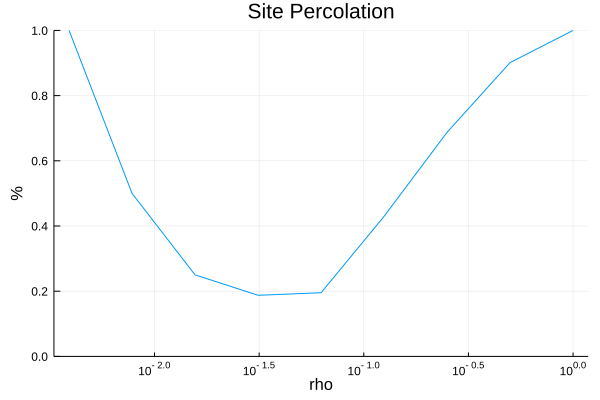

In [36]:
L = 16
T = 401

p_I = 1/3
p_M = 0

loop_count = 8

rhos = []
I_fracs = []

for N in logspace(1,L^2,9)
  print(".")
  
  rho = N / (L^2)
  push!(rhos, rho)
  
  cur_I_frac = 0
  for _ in 1:loop_count
    cur_agents = initialize(L, N)
    cur_states, Ss, Is, Rs = social_dynamics!(cur_agents, L, p_I, p_M, T) 
    cur_I_frac += Is[end]
  end
  cur_I_frac /= ( N * loop_count )
  
  push!(I_fracs, cur_I_frac)
end

plot(rhos, I_fracs, xscale=:log10, label="")
ylims!(0,1)
plot!(xlabel="rho", ylabel="%", title="Site Percolation")

### 2. When we start to increase $p_M$, we allow some local motion via random walk
Investigate how this leaky quarantine affects the infection dynamics with
different densities

In [37]:
L = 20
N = 100
T = 360

p_M_values = sort([
  ( 1 * 10.0 .^ (-2:0) )...,
  ( 5 * 10.0 .^ (-3:-1) )...
])

p_I_values = [1/100, 5/100, 1/10, 5/10, 1/1]

social_agents = initialize(L, N)

si_dict = Dict()
for p_M in p_M_values
  for p_I in p_I_values
    tmp_agents = deepcopy(social_agents)
    si_dict[(p_I,p_M)] = social_dynamics!(tmp_agents, L, p_I, p_M, T) 
  end
end

@manipulate for t in 0:30:T, p_M = p_M_values, p_I in p_I_values
  if t == 0
    cur_states = [social_agents]
    Ss = [length(social_agents) - 1]
    Is = [1]
    Rs = [0]
  else
    cur_states, Ss, Is, Rs = si_dict[(p_I,p_M)]
  end
  custom_plot(cur_states, Ss, Is, Rs, t, L)
end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["t"], Dict{Symbol,Any}(:className => "interact ",:style => Dict{Any,Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol,Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol,Any}(:max => 13,:min => 1,:attributes => Dict{Any,Any}(:type => "range",Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}","orient" => "horizontal"),:step => 1,:className => "slider slider is-fullwidth",:style => Dict{Any,Any}()))], Dict{Symbol,Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol,Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol,Any}(:className => "interact-flex-row-right"))], Dict{Symbol,Any}(:className => "interact-flex-row interact-widget")), Dict{String,Tuple{Observables.AbstractObservable,Union{Nothing, Bool}}}("changes" => (Observable{Int64} with 1 listeners. Value:
0, nothing),"index" => (Observable{Any} with 2 listeners. Value:
7, nothing)), Set(String[]), nothing, Asset[Asset("js", "knockout", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/all.js"), Asset("css", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/style.css"), Asset("css", nothing, "/Users/dan/.julia/packages/Interact/SbgIk/src/../assets/bulma_confined.min.css")], Dict{Any,Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")],"index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(sz_max:32,sz_curr:0), Set(AbstractConnection[]), Base.GenericCondition{Base.AlwaysLockedST}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x0000000114515450, Task (runnable) @0x0000000114515450), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"0\",\"30\",\"60\",\"90\",\"120\",\"150\",\"180\",\"210\",\"240\",\"270\",\"300\",\"330\",\"360\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"16212900897078884015\",\"id\":\"7870801262281622158\",\"type\":\"observable\"}),\"index\":WebIO.getval

----

## Extra Credit: Web Dashboard

In [ ]:
# load file with custom plot extractor

include("dont_manipulate.jl")


In [ ]:
p_II_values = [5/100, 1/10, 5/10, 1/1]
p_RR_values = p_II_values ./ 10

p_I_slider = slider(p_II_values, value=5/10, label="p_I")
p_R_slider = slider(p_RR_values, value=1/100, label="p_R")

work_agents = initialize(L, N)

sir_dict = Dict()
for p_I in p_II_values
  for p_R in p_RR_values
    tmp_agents = deepcopy(work_agents)
    sir_dict[(p_I,p_R)] = dynamics!(tmp_agents, L, p_I, p_R, T) 
  end
end


In [ ]:
plotlyjs()

@dont_manipulate "../docs/assets/json/social-distancing.json" for t in 0:30:T, p_M = p_M_values, p_I in p_I_values
  if t == 0
    cur_states = [social_agents]
    Ss = [length(social_agents) - 1]
    Is = [1]
    Rs = [0]
  else
    cur_states, Ss, Is, Rs = si_dict[(p_I,p_M)]
  end
  custom_plot(cur_states, Ss, Is, Rs, t, L, true)
end

@dont_manipulate "../docs/assets/json/random-walk.json" for t in 0:30:T, p_R = p_R_slider , p_I = p_I_slider
  if t == 0
    cur_states = [work_agents]
    Ss = [length(work_agents) - 1]
    Is = [1]
    Rs = [0]
  else
    cur_states, Ss, Is, Rs = sir_dict[(p_I,p_R)]
  end
  custom_plot(cur_states, Ss, Is, Rs, t, L, true)
end

gr()
